In [3]:
import os
import pickle
from datetime import datetime

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


In [8]:
# ── Fig 10: distribution of DSR coefficients per ROI ─────────────────
# Each DSR neuron has 324 coefficients arranged as
#   (location, phase, future-lag) = (9, 3, 12).
# Coefs are saved per held-out fold in diagnostics.pkl; for this plot we
# take the across-fold mean so each neuron contributes one (324,) vector.
# Then per ROI we look at the distribution of those values, collapsed over
# the two factors NOT on the x-axis.
RESULT_DIR = ('/Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/encoding_analysis_simple/2026-05-19_17-26-12/')

DIAGNOSTICS_PKL = os.path.join(RESULT_DIR, 'diagnostics.pkl')
DSR_MODEL_NAME  = 'dsr'
DSR_N_LOCATIONS = 9
DSR_N_PHASES    = 3
DSR_N_LAGS      = 12          # 'future lag' index (== n_clocks_per_phase)
DSR_N_COEFS     = DSR_N_LOCATIONS * DSR_N_PHASES * DSR_N_LAGS  # 324
DSR_PHASE_NAMES = ('early', 'middle', 'late')

# Only include DSR-encoding neurons (across-fold permutation p_perm < this).
DSR_COEF_P_PERM_THRESHOLD = 0.05

# Per-neuron coefficient normalisation, so neurons with different firing-rate
# scales contribute equally to the population summary.  Options:
#   'sum' — coef / sum(coef)        (probability-distribution interpretation)
#   'l2'  — coef / ||coef||_2       (unit-norm)
#   'max' — coef / max(coef)        (peak-relative)
#   None  — raw coefficients
DSR_COEF_NORMALIZE = 'sum'

# ROIs used as columns in the detailed histogram-grid plots.
DSR_COEF_HISTOGRAM_ROIS = ['ACC', 'HC_anterior', 'HC_posterior']
print(f"\nLoading DSR coefficients from {DIAGNOSTICS_PKL}")
with open(DIAGNOSTICS_PKL, 'rb') as f:
    _diagnostics = pickle.load(f)
print(f"  loaded diagnostics for {len(_diagnostics)} subjects.")



Loading DSR coefficients from /Users/xpsy1114/Documents/projects/multiple_clocks/data/ephys_humans/derivatives/group/encoding_analysis_simple/2026-05-19_17-26-12/diagnostics.pkl
  loaded diagnostics for 63 subjects.


In [10]:
print("  DSR coefficient indexing reminder:")
print(f"    324 coefficients per neuron, arranged as "
      f"(location 1..{DSR_N_LOCATIONS}) × (phase {DSR_PHASE_NAMES}) "
      f"× (lag 0..{DSR_N_LAGS - 1})")
print("    coefs[loc * 36 + phase * 12 + lag]")
print(f"    per-neuron normalisation = {DSR_COEF_NORMALIZE!r}, "
      f"p_perm threshold = {DSR_COEF_P_PERM_THRESHOLD}")

dsr_coefs_df = load_dsr_coefs(
    _diagnostics,
    p_perm_threshold=DSR_COEF_P_PERM_THRESHOLD,
    normalize=DSR_COEF_NORMALIZE,
)
print(f"  {len(dsr_coefs_df)} DSR-encoding neurons kept "
      f"(p_perm < {DSR_COEF_P_PERM_THRESHOLD}).")
print("  per-ROI counts:")
print(dsr_coefs_df['roi'].value_counts().to_string())


  DSR coefficient indexing reminder:
    324 coefficients per neuron, arranged as (location 1..9) × (phase ('early', 'middle', 'late')) × (lag 0..11)
    coefs[loc * 36 + phase * 12 + lag]
    per-neuron normalisation = 'sum', p_perm threshold = 0.05
  load_dsr_coefs: kept 166; filtered: p_perm=818, zero-coef=0, missing=0, wrong-shape=0
  166 DSR-encoding neurons kept (p_perm < 0.05).
  per-ROI counts:
HC_anterior        45
HC_posterior       36
ACC                28
posterior_PCC      13
OFC11              12
Visual             11
OFC13               9
Parahippocampal     9
EC                  2
ventral_ACC         1


In [18]:
def _normalize_coefs(coefs, how):
    """Per-neuron normalisation; returns (coefs_norm, ok).

    `ok` is False when the normaliser cannot be computed (e.g. an
    all-zero coefficient vector), so the caller can drop that neuron.
    """
    if how is None:
        return coefs, True
    coefs = np.asarray(coefs, dtype=float)
    if how == 'sum':
        s = float(coefs.sum())
        if s <= 1e-12:
            return coefs, False
        return coefs / s, True
    if how == 'l2':
        s = float(np.sqrt((coefs ** 2).sum()))
        if s <= 1e-12:
            return coefs, False
        return coefs / s, True
    if how == 'max':
        s = float(np.max(np.abs(coefs)))
        if s <= 1e-12:
            return coefs, False
        return coefs / s, True
    raise ValueError(f"Unknown normalisation: {how!r}")


def load_dsr_coefs(diagnostics,
                   p_perm_threshold=DSR_COEF_P_PERM_THRESHOLD,
                   normalize=DSR_COEF_NORMALIZE,
                   model_name=DSR_MODEL_NAME,
                   expected_size=DSR_N_COEFS):
    """Per-neuron across-fold-mean DSR coefficients, tagged with ROI.

    Parameters
    ----------
    p_perm_threshold : float or None
        Only keep neurons whose `p_perm` for this model is < threshold.
        ``None`` keeps every neuron.
    normalize : 'sum' | 'l2' | 'max' | None
        Per-neuron normalisation so the resulting coefficients are
        comparable across neurons with very different firing-rate scales.

    Returns DataFrame with columns:
        subject, neuron, roi, p_perm, mean_r, coefs (size 324, normalised).
    """
    rows, skipped = [], {
        'missing': 0, 'wrong_shape': 0,
        'p_perm': 0, 'zero_coefs': 0,
    }
    for sub, per_neuron in diagnostics.items():
        for n_lab, per_model in per_neuron.items():
            if model_name not in per_model:
                skipped['missing'] += 1
                continue
            d = per_model[model_name]

            # p_perm filter (only DSR-encoding neurons).
            if p_perm_threshold is not None:
                p = d.get('p_perm', np.nan)
                if not np.isfinite(p) or p >= p_perm_threshold:
                    skipped['p_perm'] += 1
                    continue

            coefs_list = d.get('coefs', [])
            if not coefs_list:
                skipped['missing'] += 1
                continue
            coefs_arr = np.array(
                [np.asarray(c, dtype=float) for c in coefs_list]
            )
            if coefs_arr.ndim != 2 or coefs_arr.shape[1] != expected_size:
                skipped['wrong_shape'] += 1
                continue
            mean_coefs = np.mean(coefs_arr, axis=0)              # (324,)

            mean_coefs, ok = _normalize_coefs(mean_coefs, normalize)
            if not ok:
                skipped['zero_coefs'] += 1
                continue

            rows.append({
                'subject': sub,
                'neuron':  n_lab,
                'roi':     d.get('roi'),
                'p_perm':  d.get('p_perm'),
                'mean_r':  d.get('mean_r'),
                'coefs':   mean_coefs,
            })

    print(f"  load_dsr_coefs: kept {len(rows)}; "
          f"filtered: p_perm={skipped['p_perm']}, "
          f"zero-coef={skipped['zero_coefs']}, "
          f"missing={skipped['missing']}, "
          f"wrong-shape={skipped['wrong_shape']}")
    return pd.DataFrame(rows)


def reshape_dsr(coefs):
    """(324,) → (9, 3, 12) = (location, phase, lag)."""
    return np.asarray(coefs, dtype=float).reshape(
        DSR_N_LOCATIONS, DSR_N_PHASES, DSR_N_LAGS)


def per_neuron_by_factor(coefs_df, factor):
    """(n_neurons, n_bins) — mean coefficient strength per neuron per bin,
    collapsed over the two factors not equal to `factor`."""
    arrs = np.stack([reshape_dsr(c) for c in coefs_df['coefs']])  # (N,9,3,12)
    if factor == 'lag':       return arrs.mean(axis=(1, 2))       # (N, 12)
    if factor == 'location':  return arrs.mean(axis=(2, 3))       # (N, 9)
    if factor == 'phase':     return arrs.mean(axis=(1, 3))       # (N, 3)
    raise ValueError(f"Unknown factor: {factor!r}")


def _friedman_test_across_bins(vals):
    """Friedman omnibus: do bins differ within-neuron?  Returns p-value."""
    n_neu, n_bins = vals.shape
    if n_neu < 2 or n_bins < 2:
        return np.nan
    cols = [vals[:, b] for b in range(n_bins)]
    try:
        return float(stats.friedmanchisquare(*cols).pvalue)
    except (ValueError, TypeError):
        return np.nan


def _per_bin_vs_grand_mean(vals):
    """Paired Wilcoxon per bin: val[bin] vs the neuron's mean across bins.

    Returns (p_corr, signs) — Bonferroni-corrected two-sided p per bin and
    sign of the median deviation from the grand mean (+1 above, -1 below).
    """
    n_neu, n_bins = vals.shape
    p_vals = np.full(n_bins, np.nan, dtype=float)
    signs  = np.zeros(n_bins, dtype=int)
    if n_neu < 2:
        return p_vals, signs
    grand_mean = vals.mean(axis=1, keepdims=True)
    centred = vals - grand_mean
    for b in range(n_bins):
        d = centred[:, b]
        if np.all(d == 0):
            continue
        try:
            res = stats.wilcoxon(d, alternative='two-sided',
                                 zero_method='wilcox')
            p_vals[b] = float(res.pvalue)
            signs[b]  = 1 if np.nanmedian(d) > 0 else -1
        except (ValueError, TypeError):
            pass
    return np.minimum(1.0, p_vals * n_bins), signs


def _print_bin_statistics(coefs_df, factor, rois, label, bin_labels):
    """Console summary of per-bin statistics, per ROI."""
    print(f"\n  --- DSR coef stats by {label} "
          f"(per-neuron norm={DSR_COEF_NORMALIZE!r}, "
          f"Bonferroni-corrected vs grand mean) ---")
    for roi in rois:
        sub = coefs_df[coefs_df['roi'] == roi]
        if sub.empty:
            continue
        vals = per_neuron_by_factor(sub, factor=factor)
        n = len(vals)
        omni_p = _friedman_test_across_bins(vals)
        p_corr, signs = _per_bin_vs_grand_mean(vals)
        means = vals.mean(axis=0)
        sems = vals.std(axis=0) / max(1, np.sqrt(n))
        omni_str = (f"{omni_p:.3e}" if np.isfinite(omni_p) else 'nan')
        print(f"    [{roi:<14s}] n={n:3d}  Friedman p={omni_str}")
        for b, lbl in enumerate(bin_labels):
            sig = ('***' if p_corr[b] < 0.001
                   else '**' if p_corr[b] < 0.01
                   else '*' if p_corr[b] < 0.05
                   else 'n.s.')
            direction = '↑' if signs[b] > 0 else '↓' if signs[b] < 0 else '–'
            p_str = (f"{p_corr[b]:.3e}" if np.isfinite(p_corr[b]) else 'nan')
            print(f"      {lbl:>10s}: mean={means[b]:+.4f} ± {sems[b]:.4f}  "
                  f"{direction}  p_corr={p_str}  {sig}")


def plot_dsr_coef_distribution_by_factor(coefs_df, factor, save_path,
                                         rois=None, n_cols=4):
    """Per-ROI distribution of DSR coefficient strength binned by `factor`.

    Shows boxplots overlaid with per-neuron jittered points so the full
    distribution is visible.  Each panel title reports the Friedman
    omnibus p-value; per-bin stars are Bonferroni-corrected paired
    Wilcoxon tests of bin vs the neuron's own grand mean (↑/↓ shows
    direction).  The per-neuron coefficients are normalised with
    DSR_COEF_NORMALIZE = {DSR_COEF_NORMALIZE!r} so neurons with different
    firing-rate scales contribute equally.
    """
    factor_meta = {
        'lag':      ('future lag', [str(i) for i in range(DSR_N_LAGS)]),
        'location': ('location',
                     [str(i + 1) for i in range(DSR_N_LOCATIONS)]),
        'phase':    ('phase', list(DSR_PHASE_NAMES)),
    }
    label, bin_labels = factor_meta[factor]

    if rois is None:
        rois = sorted(coefs_df['roi'].dropna().unique().tolist())
    if not rois:
        print(f"  no ROIs to plot for {factor}; skipping.")
        return

    n = len(rois)
    ncols = min(n_cols, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 3.6, nrows * 2.9),
        squeeze=False,
    )

    # Shared y-limits across panels for fair comparison.
    all_vals = []
    for roi in rois:
        sub = coefs_df[coefs_df['roi'] == roi]
        if not sub.empty:
            all_vals.append(per_neuron_by_factor(sub, factor=factor).ravel())
    if all_vals:
        pooled = np.concatenate(all_vals)
        y_max = 1.10 * float(np.nanpercentile(pooled, 99))
        y_min = min(0.0, float(np.nanmin(pooled)))
    else:
        y_min, y_max = 0.0, 1.0

    rng = np.random.default_rng(0)
    for ax_idx, roi in enumerate(rois):
        ax = axes[ax_idx // ncols, ax_idx % ncols]
        sub_df = coefs_df[coefs_df['roi'] == roi]
        n_neu = len(sub_df)
        if n_neu == 0:
            ax.set_title(f'{roi}: no neurons', fontsize=9)
            ax.axis('off')
            continue

        vals = per_neuron_by_factor(sub_df, factor=factor)  # (n_neu, n_bins)
        positions = np.arange(len(bin_labels))

        # Boxplot (distribution per bin across neurons).
        ax.boxplot(vals, positions=positions, showfliers=False, widths=0.55,
                   medianprops={'color': 'tab:blue'},
                   whiskerprops={'color': '0.4'},
                   capprops={'color': '0.4'},
                   boxprops={'color': '0.4'})

        # Jittered raw points so the full distribution is visible.
        for b in range(len(bin_labels)):
            xs = positions[b] + (rng.uniform(-0.18, 0.18, size=n_neu))
            ax.scatter(xs, vals[:, b], s=6, color='tab:blue',
                       alpha=0.4, edgecolor='none')

        # Mean line on top.
        ax.plot(positions, np.nanmean(vals, axis=0),
                color='tab:red', lw=1.4, marker='o', ms=4, zorder=5)

        # Statistics.
        omni_p = _friedman_test_across_bins(vals)
        p_corr, signs = _per_bin_vs_grand_mean(vals)
        omni_str = (f"{omni_p:.2e}" if np.isfinite(omni_p) else 'nan')
        ax.set_title(f'{roi} (n={n_neu})  Friedman p={omni_str}',
                     fontsize=9)

        # Per-bin stars + direction arrow above the box.
        for b in range(len(bin_labels)):
            if not np.isfinite(p_corr[b]):
                continue
            if   p_corr[b] < 0.001: stars = '***'
            elif p_corr[b] < 0.01:  stars = '**'
            elif p_corr[b] < 0.05:  stars = '*'
            else:                   continue
            arrow = '↑' if signs[b] > 0 else '↓'
            ax.text(positions[b], y_max * 0.97, f'{arrow}{stars}',
                    ha='center', va='top', fontsize=7,
                    color='tab:red' if signs[b] > 0 else 'tab:purple',
                    fontweight='bold')

        ax.axhline(0, color='0.6', lw=0.5, ls=':')
        ax.set_xticks(positions)
        ax.set_xticklabels(bin_labels, fontsize=7)
        ax.set_ylim(y_min, y_max)
        ax.set_xlabel(label, fontsize=8)
        if ax_idx % ncols == 0:
            ax.set_ylabel(f'coef ({DSR_COEF_NORMALIZE}-normalised)',
                          fontsize=8)
        ax.tick_params(axis='y', labelsize=7)

    for k in range(n, nrows * ncols):
        axes[k // ncols, k % ncols].axis('off')

    fig.suptitle(
        f'DSR coefficient strength by {label} '
        f'(per-neuron {DSR_COEF_NORMALIZE}-normalised, '
        f'p_perm<{DSR_COEF_P_PERM_THRESHOLD})  '
        f'— ↑/↓ Bonferroni-corrected vs grand mean: *p<.05 **p<.01 ***p<.001',
        fontsize=9,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    #fig.savefig(save_path, dpi=150)
    #plt.close(fig)
    #print(f"Wrote {save_path}")

    _print_bin_statistics(coefs_df, factor, rois, label, bin_labels)


def plot_dsr_coef_overlay_across_rois(coefs_df, save_path, rois=None):
    """Mean ± SEM coefficient strength for every ROI overlaid; three
    panels (lag, location, phase) side by side."""
    if rois is None:
        rois = sorted(coefs_df['roi'].dropna().unique().tolist())
    if not rois:
        print("  no ROIs to plot for overlay; skipping.")
        return

    factors = [
        ('lag',      'future lag',
         [str(i) for i in range(DSR_N_LAGS)]),
        ('location', 'location',
         [str(i + 1) for i in range(DSR_N_LOCATIONS)]),
        ('phase',    'phase', list(DSR_PHASE_NAMES)),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), squeeze=False)
    cmap = plt.get_cmap('tab10')

    for ax, (factor, xlabel, labels) in zip(axes[0], factors):
        for r_idx, roi in enumerate(rois):
            sub = coefs_df[coefs_df['roi'] == roi]
            if sub.empty:
                continue
            vals = per_neuron_by_factor(sub, factor=factor)   # (n, k)
            n = len(vals)
            m = np.nanmean(vals, axis=0)
            sem = np.nanstd(vals, axis=0) / max(1, np.sqrt(n))
            x = np.arange(len(labels))
            color = cmap(r_idx % 10)
            ax.plot(x, m, color=color, lw=1.4, marker='o', ms=4,
                    label=f'{roi} (n={n})')
            ax.fill_between(x, m - sem, m + sem, color=color, alpha=0.15)
        ax.axhline(0, color='0.6', lw=0.5, ls=':')
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=7)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('mean coef', fontsize=9)
        ax.set_title(f'DSR coef vs {xlabel}', fontsize=10)

    axes[0, -1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                       fontsize=7, frameon=False)
    fig.suptitle('Per-ROI DSR coefficient mean ± SEM', fontsize=11)
    fig.tight_layout(rect=[0, 0, 0.88, 0.93])
    #fig.savefig(save_path, dpi=150, bbox_inches='tight')
    #plt.close(fig)
    #print(f"Wrote {save_path}")


def plot_dsr_coef_histograms_by_factor(coefs_df, factor, save_path,
                                       rois=DSR_COEF_HISTOGRAM_ROIS,
                                       n_bins_hist=30):
    """Grid of per-bin coefficient histograms — rows = bins of `factor`,
    columns = ROIs.

    Layout follows the user's request: left col = ACC, middle = HC_anterior,
    right = HC_posterior (whatever `rois` lists in that order).  Within each
    cell we show the across-neuron distribution of the per-neuron coefficient
    averaged over the two non-`factor` dimensions; the red line marks the
    cell's mean.  X-range and bin edges are shared so panels are directly
    comparable.
    """
    factor_meta = {
        'lag':      ('future lag', [str(i) for i in range(DSR_N_LAGS)]),
        'location': ('location',
                     [str(i + 1) for i in range(DSR_N_LOCATIONS)]),
        'phase':    ('phase', list(DSR_PHASE_NAMES)),
    }
    label, bin_labels = factor_meta[factor]
    rois_present = [r for r in rois if r in coefs_df['roi'].unique()]
    if not rois_present:
        print(f"  no requested ROIs found for {factor}; skipping histogram.")
        return
    n_bins = len(bin_labels)
    n_rois = len(rois_present)

    # Pre-compute per-ROI values once.
    vals_per_roi = {
        roi: per_neuron_by_factor(
            coefs_df[coefs_df['roi'] == roi], factor=factor)
        for roi in rois_present
    }
    pooled = np.concatenate(
        [v.ravel() for v in vals_per_roi.values() if v.size > 0]
    ) if vals_per_roi else np.array([])
    if pooled.size == 0:
        print(f"  no values to histogram for {factor}; skipping.")
        return
    x_max = float(np.nanpercentile(pooled, 99))
    x_min = min(0.0, float(np.nanmin(pooled)))
    hist_edges = np.linspace(x_min, x_max, n_bins_hist + 1)

    fig, axes = plt.subplots(
        n_bins, n_rois,
        figsize=(n_rois * 3.0, n_bins * 1.4),
        squeeze=False, sharex=True, sharey=False,
    )

    for r_idx, roi in enumerate(rois_present):
        vals = vals_per_roi[roi]
        n_neu = len(vals)
        omni_p = _friedman_test_across_bins(vals) if n_neu > 1 else np.nan
        p_corr, signs = (
            _per_bin_vs_grand_mean(vals) if n_neu > 1
            else (np.full(n_bins, np.nan), np.zeros(n_bins, dtype=int))
        )

        for b_idx in range(n_bins):
            ax = axes[b_idx, r_idx]
            if n_neu == 0:
                ax.text(0.5, 0.5, 'no neurons',
                        transform=ax.transAxes, ha='center', va='center',
                        fontsize=8)
                ax.set_xticks([]); ax.set_yticks([])
                continue
            x = vals[:, b_idx]
            ax.hist(x, bins=hist_edges, color='steelblue',
                    edgecolor='white', alpha=0.85)
            ax.axvline(0, color='0.6', lw=0.5, ls=':')
            m = float(np.nanmean(x))
            ax.axvline(m, color='tab:red', lw=1.2)

            # Per-bin annotation: corrected p vs grand mean.
            if np.isfinite(p_corr[b_idx]) and p_corr[b_idx] < 0.05:
                stars = ('***' if p_corr[b_idx] < 0.001
                         else '**' if p_corr[b_idx] < 0.01 else '*')
                arrow = '↑' if signs[b_idx] > 0 else '↓'
                ax.text(0.97, 0.92, f'{arrow}{stars}',
                        transform=ax.transAxes, ha='right', va='top',
                        fontsize=8, fontweight='bold',
                        color='tab:red' if signs[b_idx] > 0 else 'tab:purple')

            ax.tick_params(labelsize=6)
            ax.text(0.97, 0.05, f'µ={m:.3f}',
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize=6, color='tab:red')
            if r_idx == 0:
                ax.set_ylabel(f'{label} {bin_labels[b_idx]}', fontsize=7)
            if b_idx == 0:
                ax.set_title(
                    f'{roi} (n={n_neu})\nFriedman p='
                    + (f'{omni_p:.2e}' if np.isfinite(omni_p) else 'nan'),
                    fontsize=8,
                )
            if b_idx == n_bins - 1:
                ax.set_xlabel(
                    f'coef ({DSR_COEF_NORMALIZE}-normalised)', fontsize=7)

    fig.suptitle(
        f'DSR coefficient distributions by {label}  '
        f'(per-neuron {DSR_COEF_NORMALIZE}-normalised, '
        f'p_perm<{DSR_COEF_P_PERM_THRESHOLD};  '
        f'red line = mean;  arrow+star = Bonferroni p vs grand mean)',
        fontsize=10,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    #fig.savefig(save_path, dpi=150)
    #plt.close(fig)
    print(f"Wrote {save_path}")

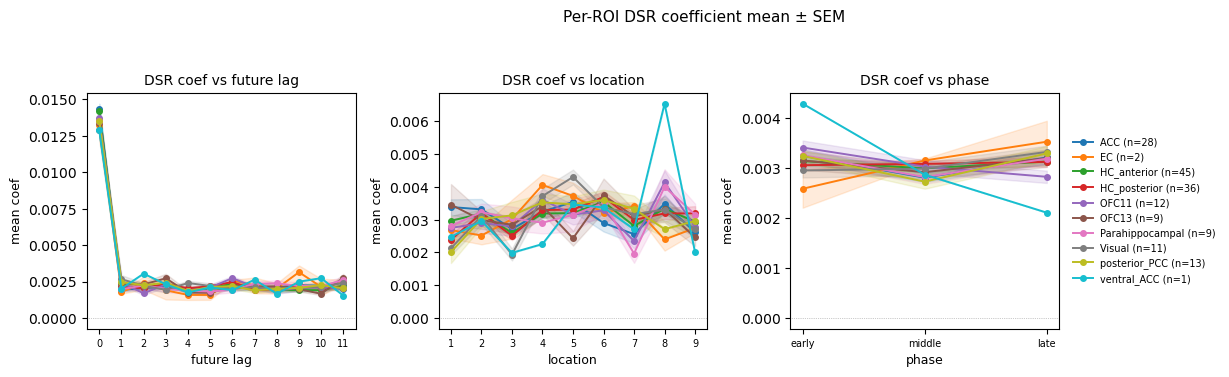

In [19]:
plot_dsr_coef_overlay_across_rois(
    dsr_coefs_df,
    save_path='x')


  --- DSR coef stats by future lag (per-neuron norm='sum', Bonferroni-corrected vs grand mean) ---
    [ACC           ] n= 28  Friedman p=5.355e-12
               0: mean=+0.0143 ± 0.0004  ↑  p_corr=8.941e-08  ***
               1: mean=+0.0019 ± 0.0001  ↓  p_corr=2.682e-07  ***
               2: mean=+0.0021 ± 0.0001  ↓  p_corr=1.788e-07  ***
               3: mean=+0.0022 ± 0.0001  ↓  p_corr=2.950e-06  ***
               4: mean=+0.0019 ± 0.0001  ↓  p_corr=4.470e-07  ***
               5: mean=+0.0020 ± 0.0001  ↓  p_corr=1.252e-06  ***
               6: mean=+0.0020 ± 0.0001  ↓  p_corr=7.868e-06  ***
               7: mean=+0.0021 ± 0.0002  ↓  p_corr=3.816e-04  ***
               8: mean=+0.0021 ± 0.0001  ↓  p_corr=7.868e-06  ***
               9: mean=+0.0022 ± 0.0001  ↓  p_corr=7.868e-06  ***
              10: mean=+0.0022 ± 0.0001  ↓  p_corr=1.699e-06  ***
              11: mean=+0.0020 ± 0.0001  ↓  p_corr=8.941e-08  ***
    [EC            ] n=  2  Friedman p=4.433e-01
          


  --- DSR coef stats by location (per-neuron norm='sum', Bonferroni-corrected vs grand mean) ---
    [ACC           ] n= 28  Friedman p=1.171e-02
               1: mean=+0.0034 ± 0.0002  ↑  p_corr=1.000e+00  n.s.
               2: mean=+0.0033 ± 0.0003  ↓  p_corr=1.000e+00  n.s.
               3: mean=+0.0027 ± 0.0002  ↓  p_corr=1.610e-01  n.s.
               4: mean=+0.0032 ± 0.0002  ↑  p_corr=1.000e+00  n.s.
               5: mean=+0.0035 ± 0.0003  ↑  p_corr=1.000e+00  n.s.
               6: mean=+0.0029 ± 0.0003  ↓  p_corr=1.000e+00  n.s.
               7: mean=+0.0026 ± 0.0003  ↓  p_corr=5.075e-01  n.s.
               8: mean=+0.0035 ± 0.0003  ↑  p_corr=1.000e+00  n.s.
               9: mean=+0.0026 ± 0.0002  ↓  p_corr=1.407e-01  n.s.
    [EC            ] n=  2  Friedman p=3.150e-01
               1: mean=+0.0027 ± 0.0003  ↓  p_corr=1.000e+00  n.s.
               2: mean=+0.0025 ± 0.0003  ↓  p_corr=1.000e+00  n.s.
               3: mean=+0.0030 ± 0.0006  ↓  p_corr=1.000e+00  n.s.


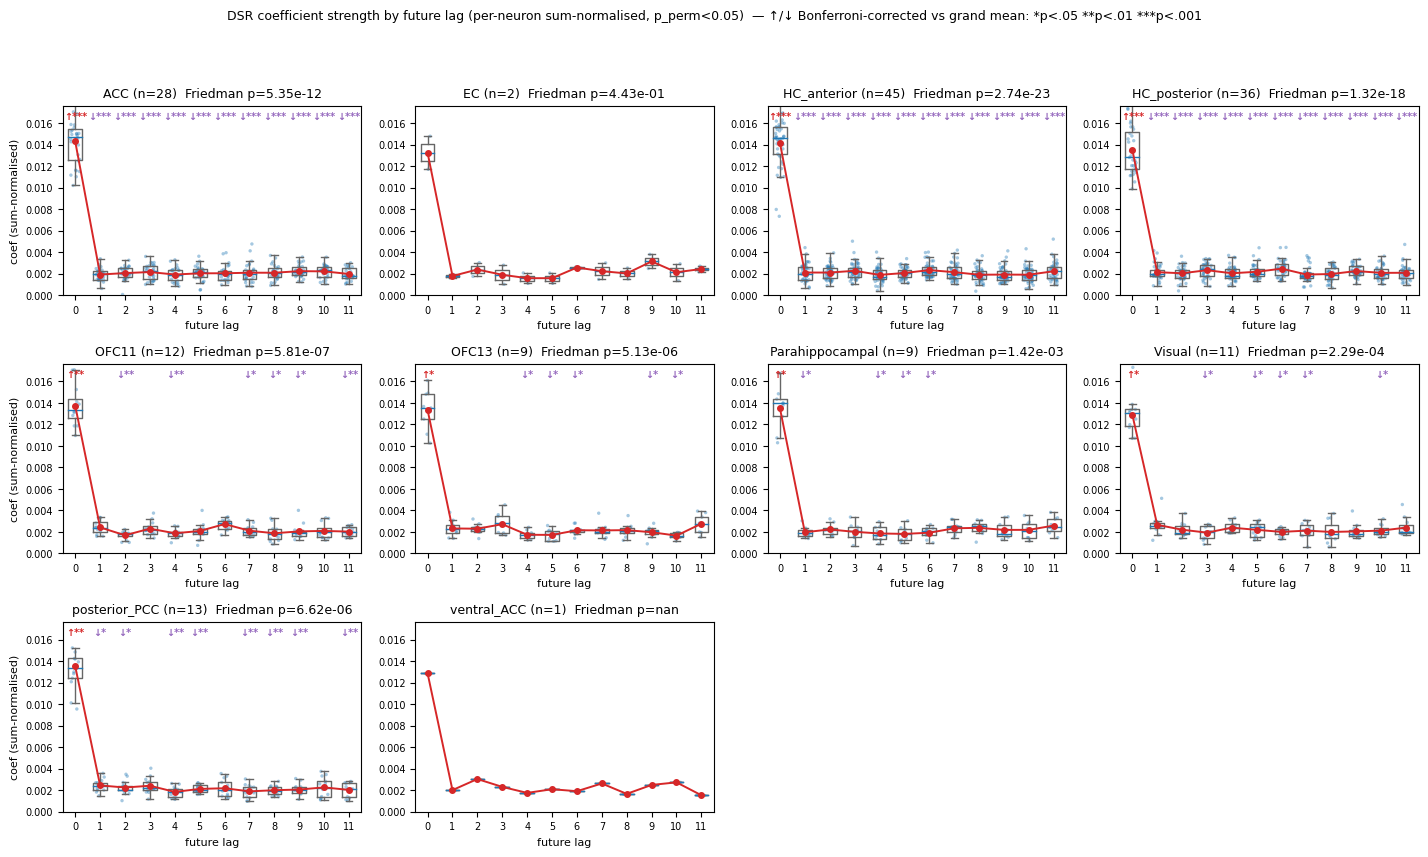

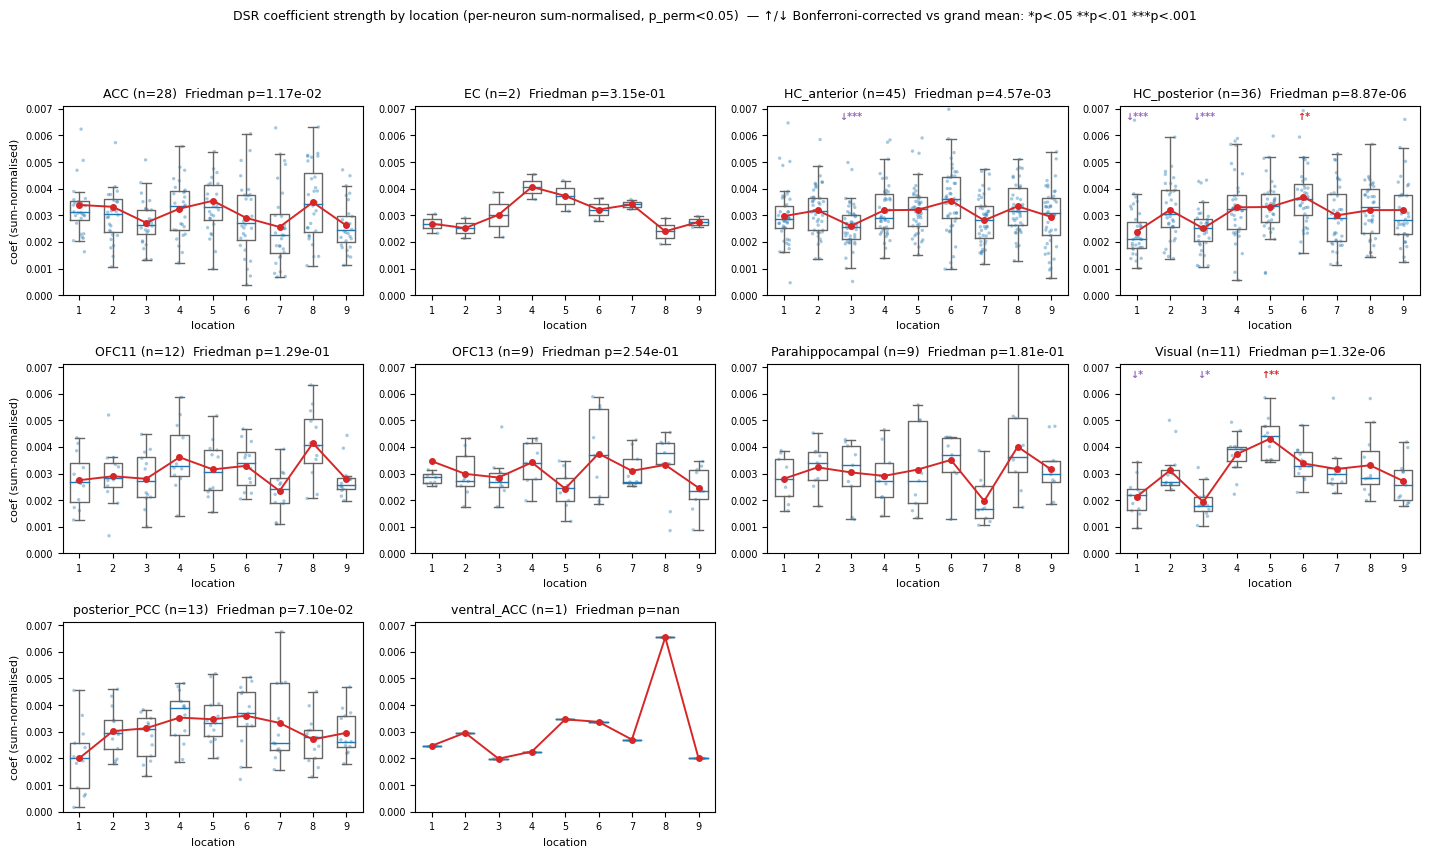

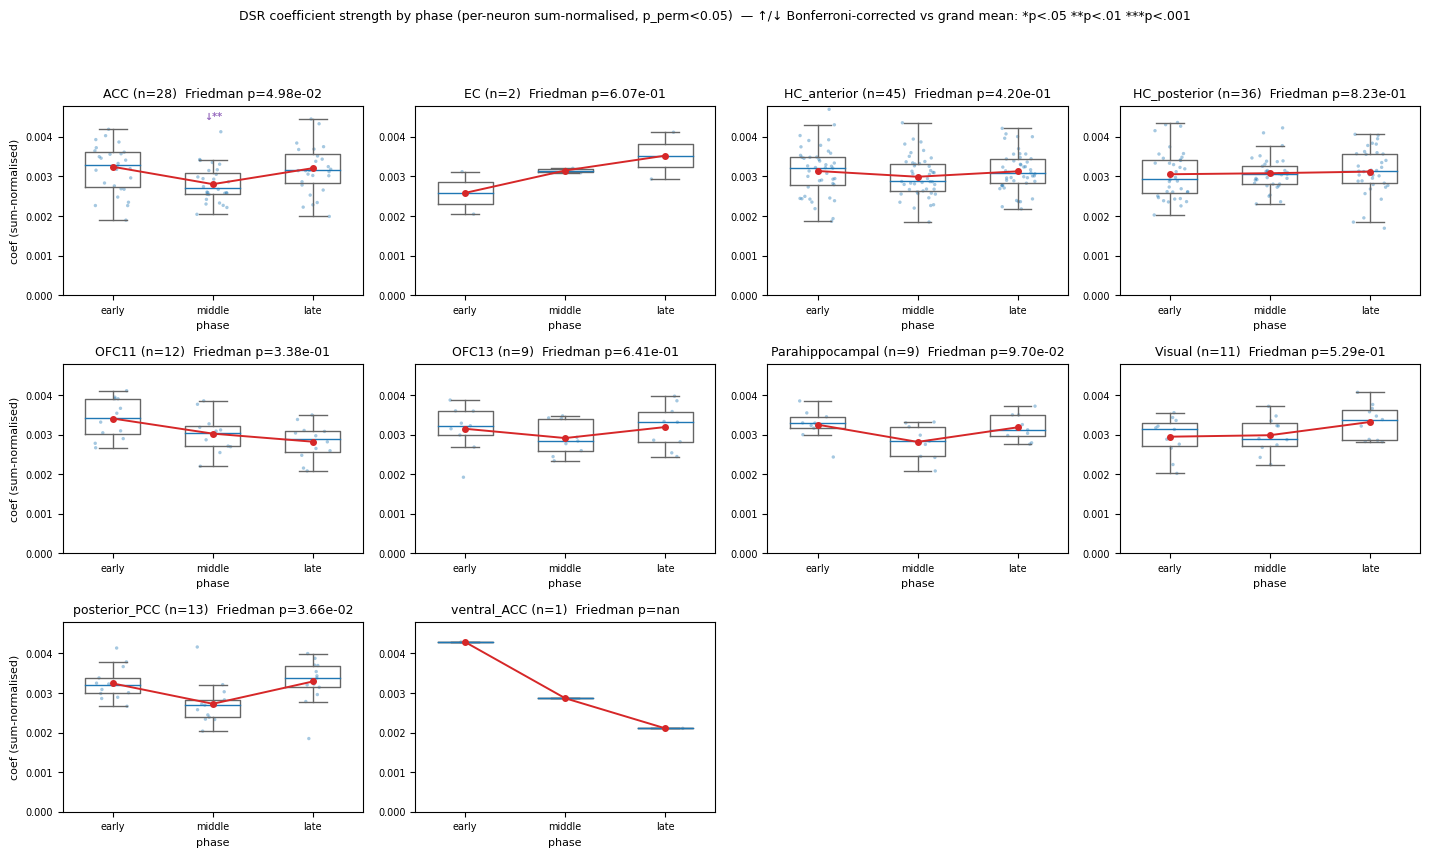

In [22]:
for factor in ['lag', 'location', 'phase']:
    plot_dsr_coef_distribution_by_factor(
        dsr_coefs_df, factor=factor,
        save_path='x')

Wrote x
Wrote x
Wrote x


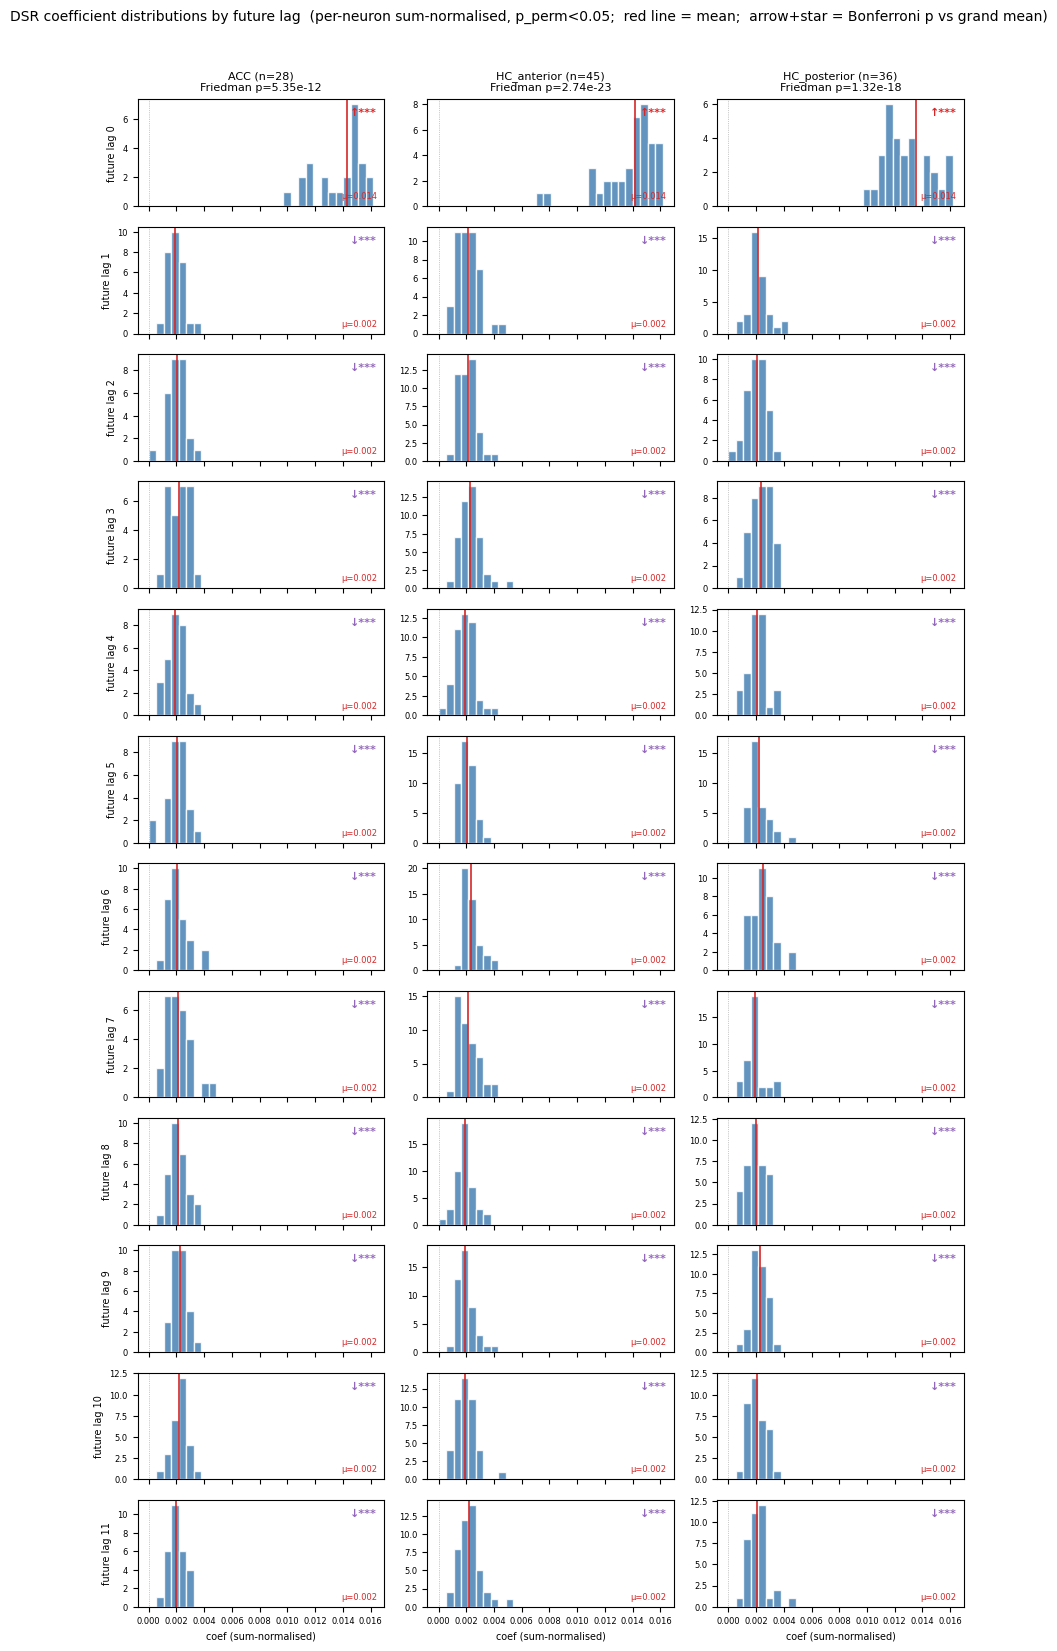

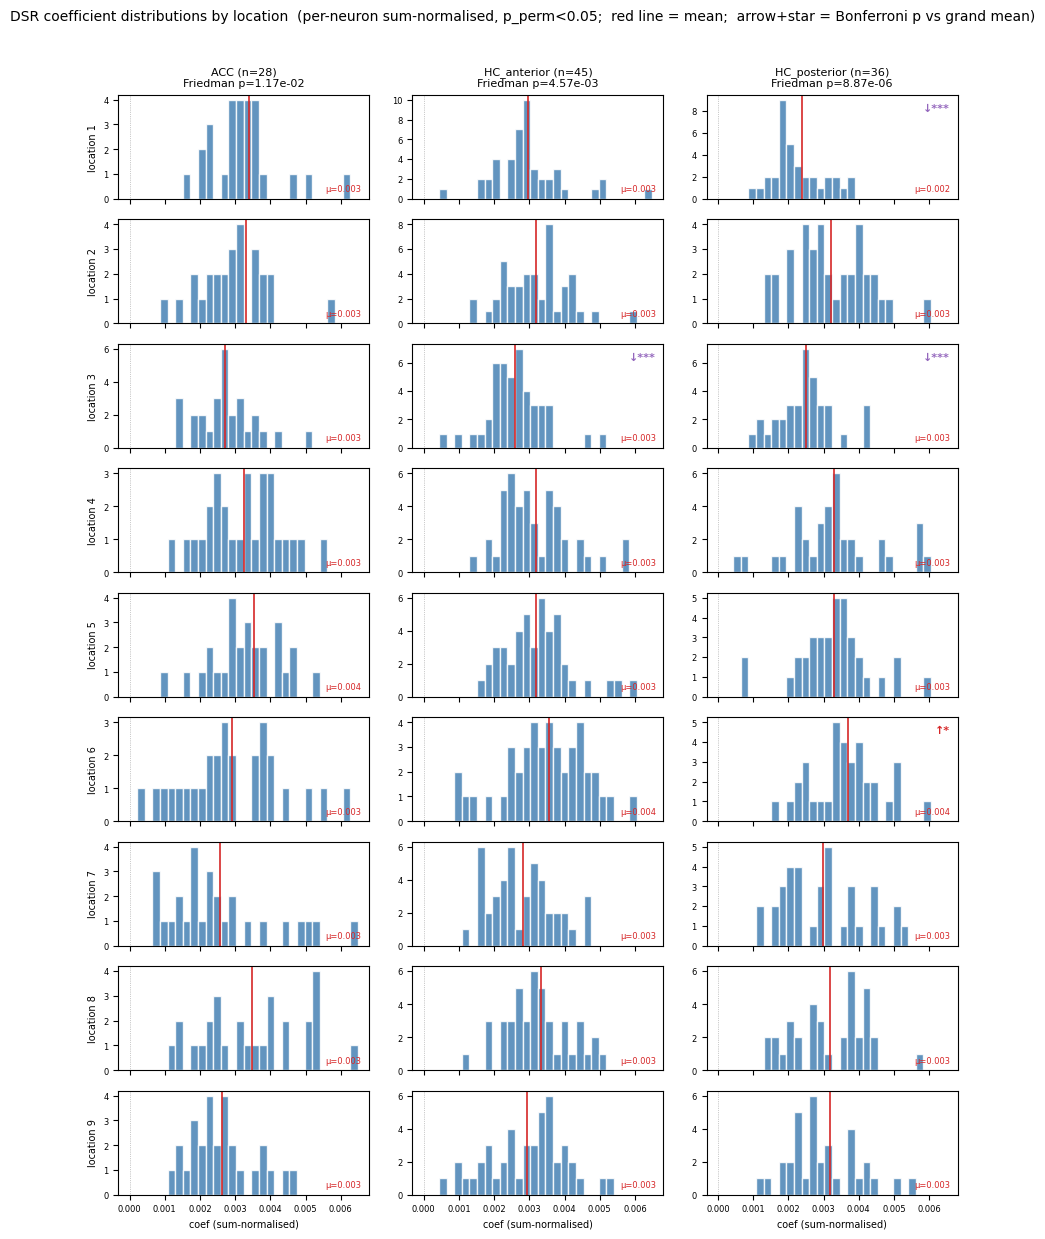

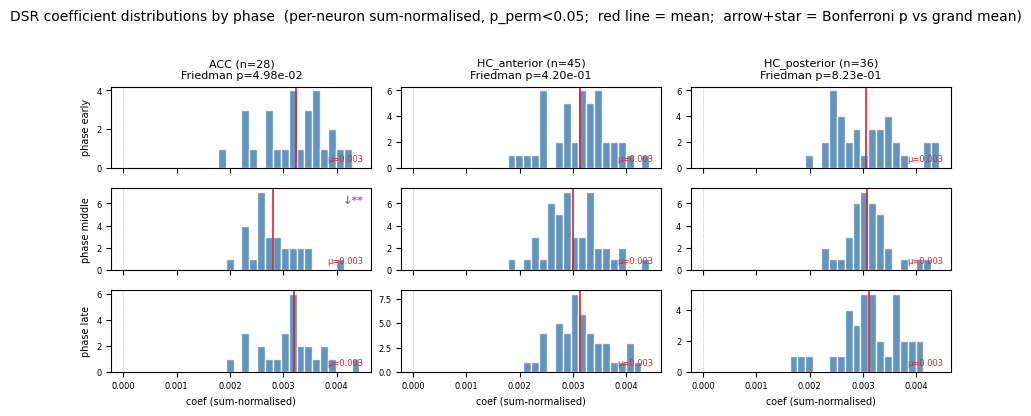

In [23]:
# Fig 11 — detailed per-bin histogram grid (rows=bins, cols=ROIs).
for factor in ['lag', 'location', 'phase']:
    plot_dsr_coef_histograms_by_factor(
        dsr_coefs_df, factor=factor,
        save_path='x',
        rois=DSR_COEF_HISTOGRAM_ROIS,
    )

/var/folders/h2/_86s79551w1734r87y2wlkk40000gt/T/ipykernel_92900/2305477681.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


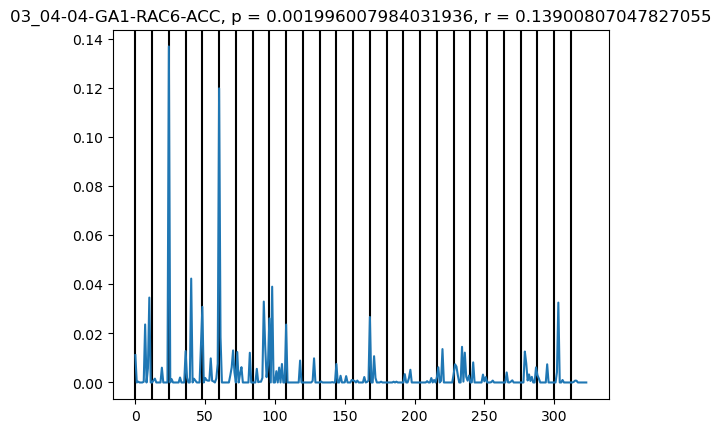

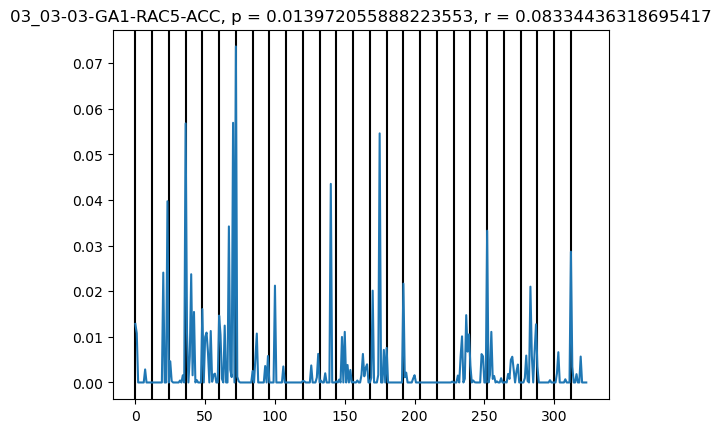

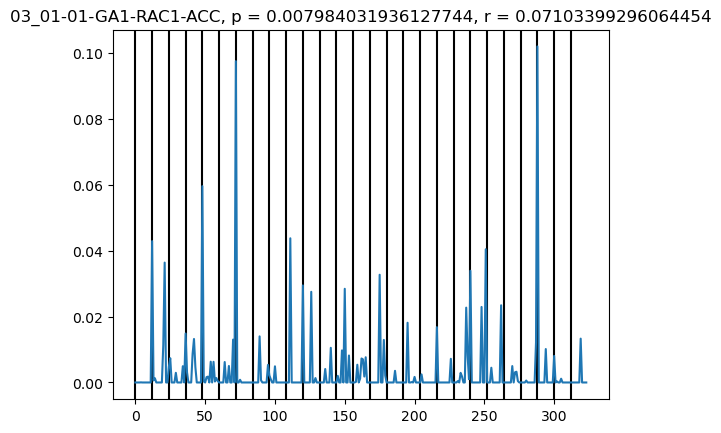

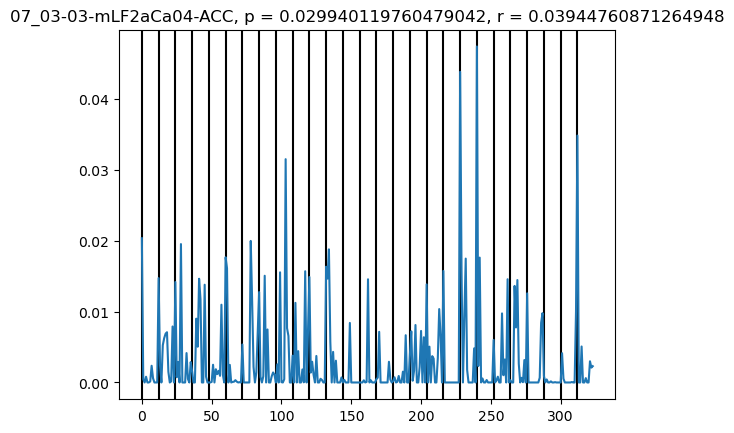

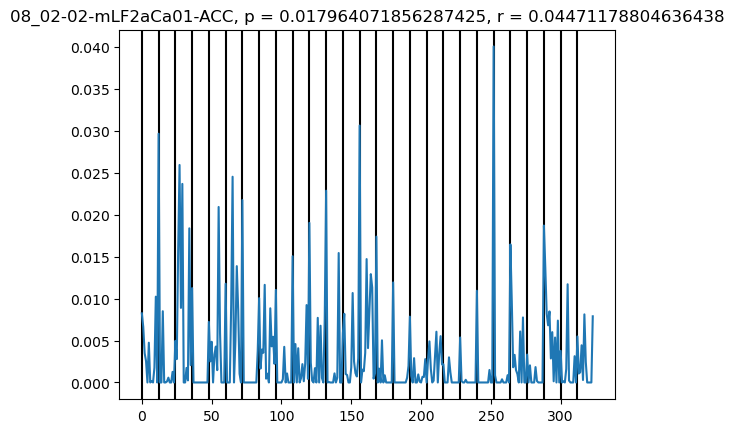

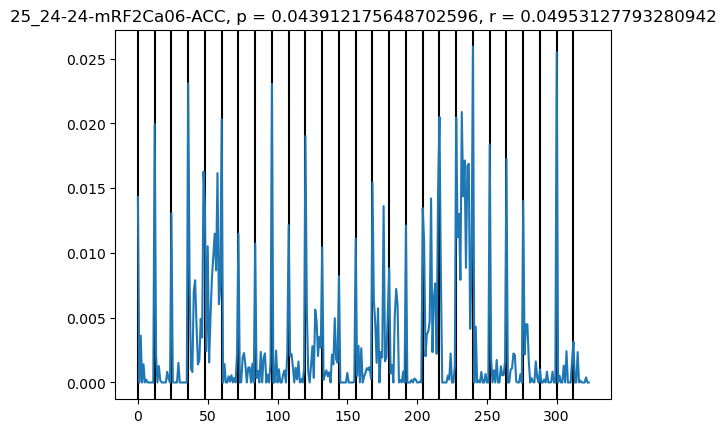

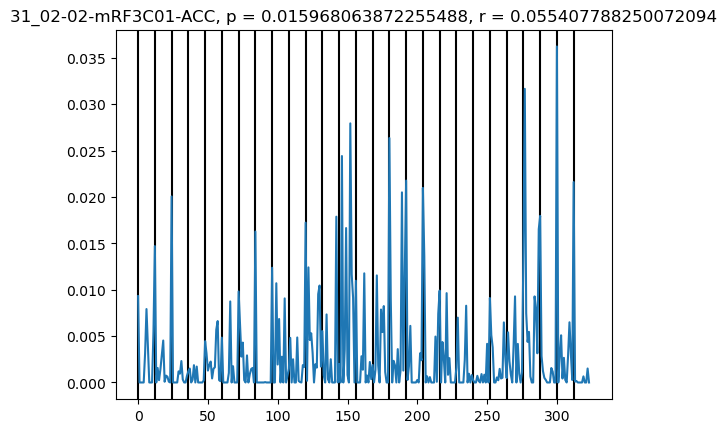

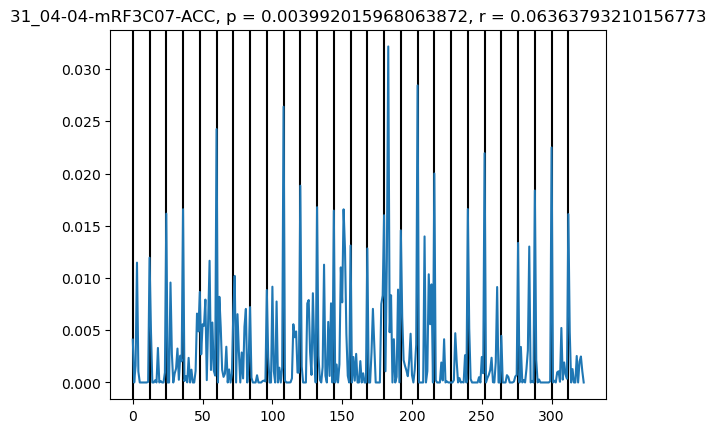

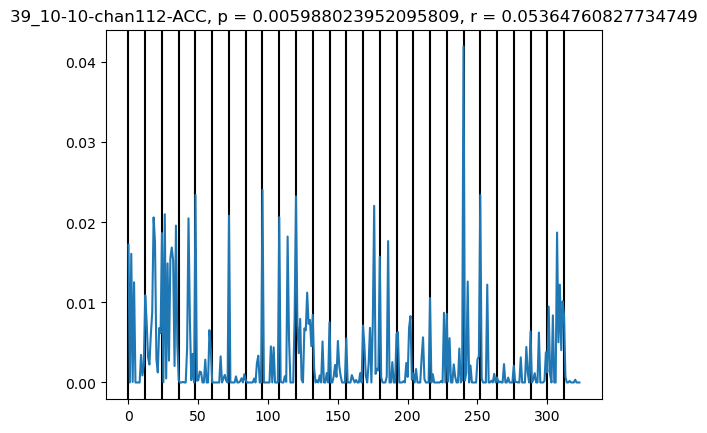

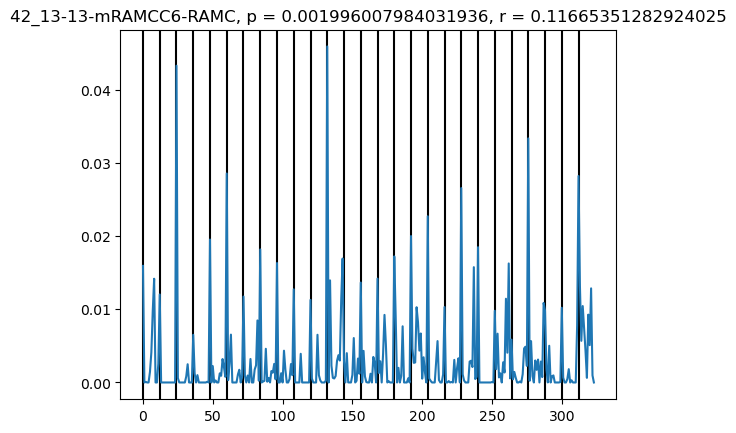

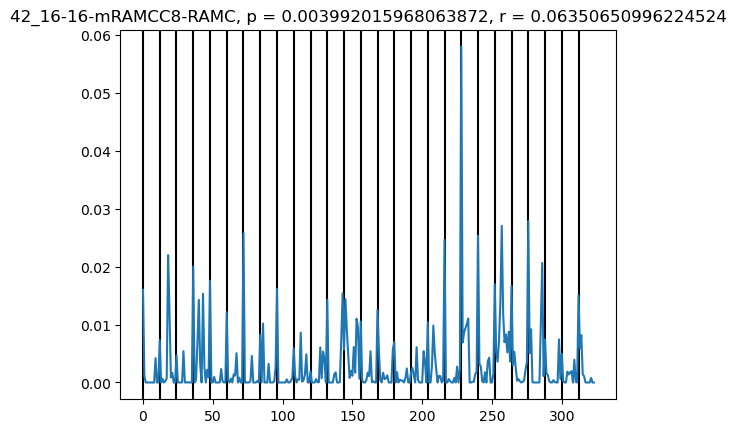

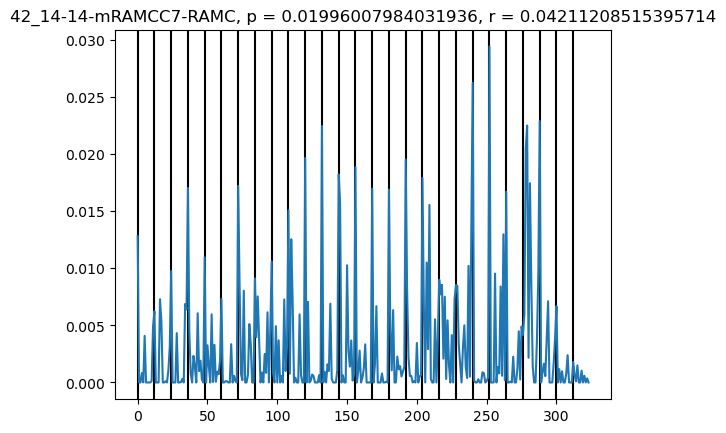

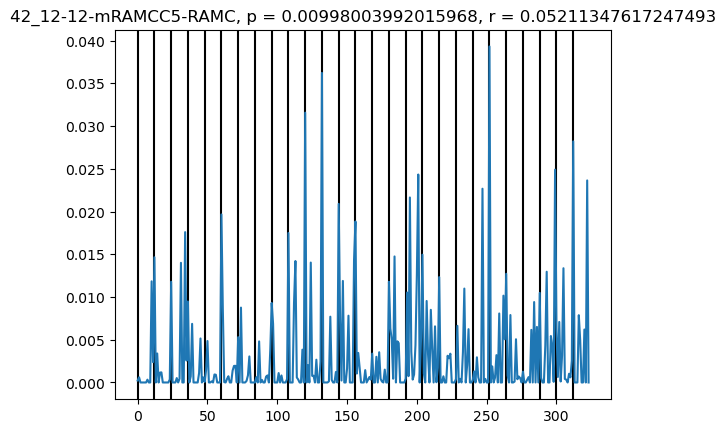

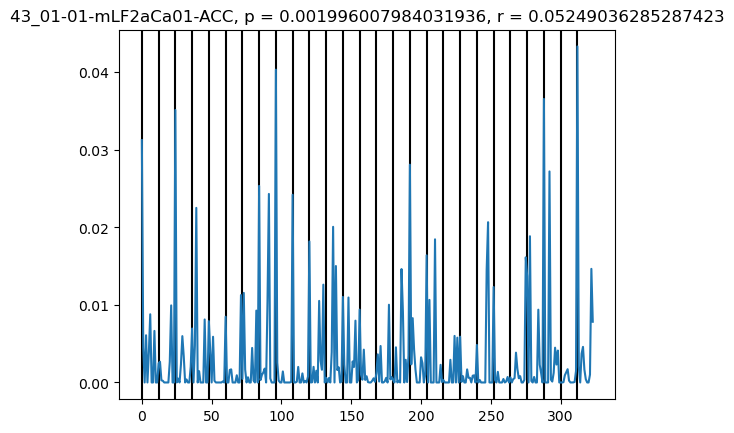

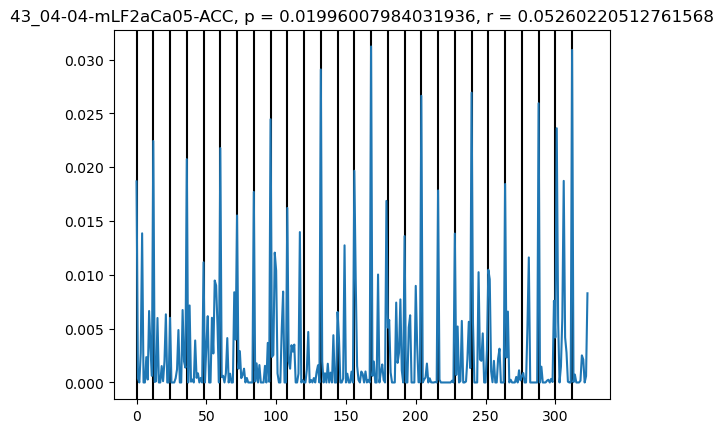

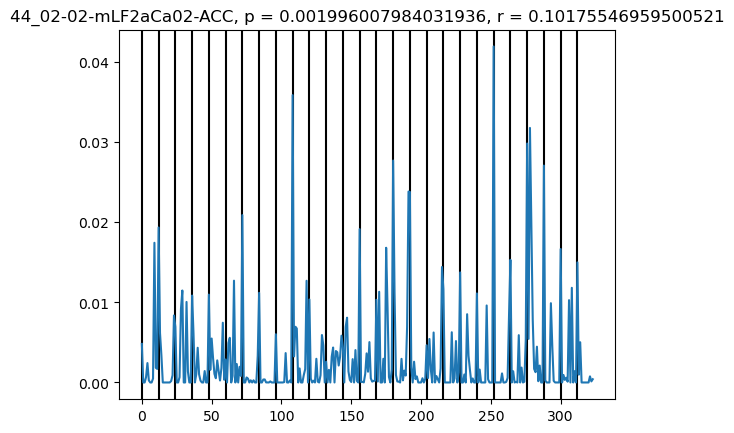

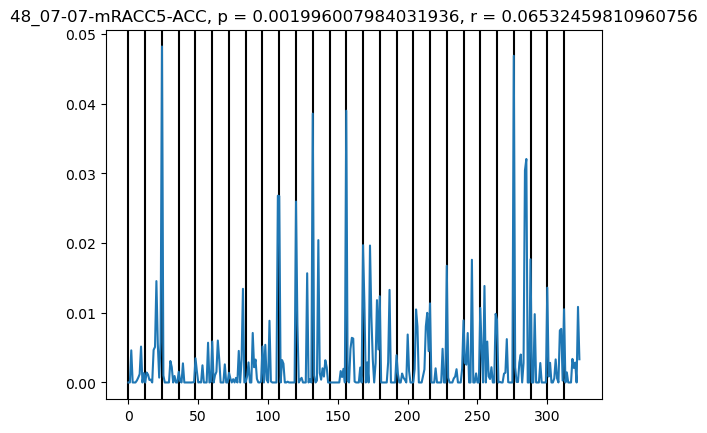

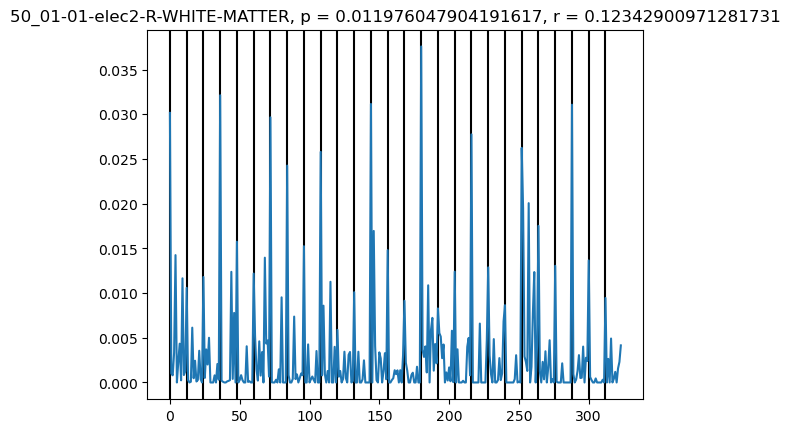

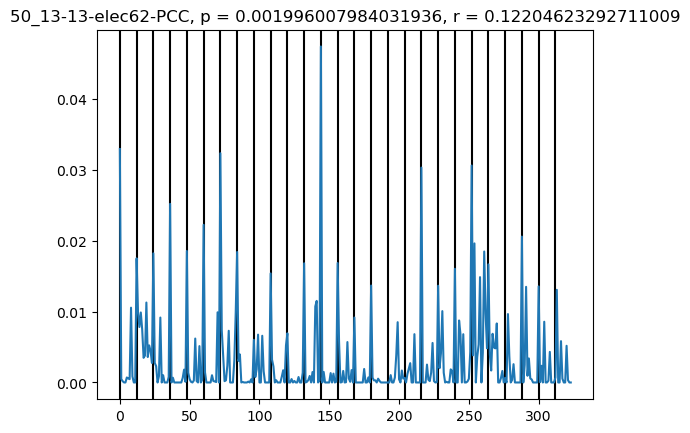

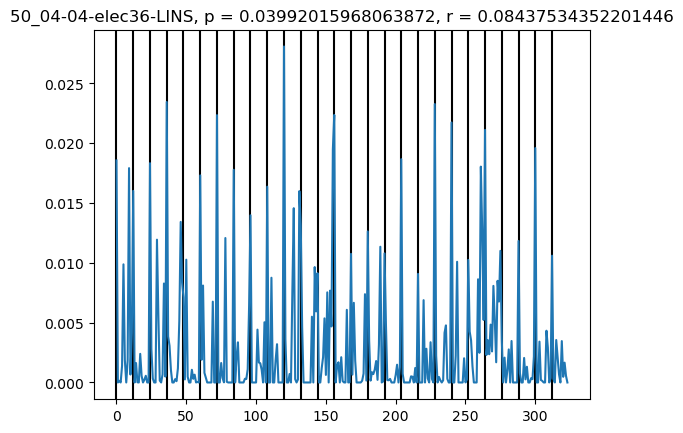

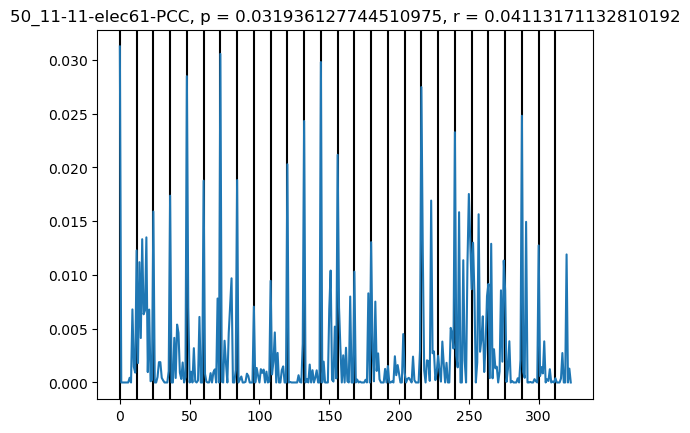

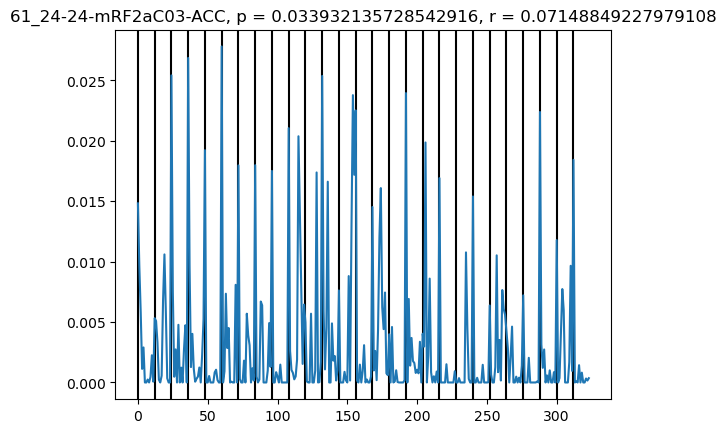

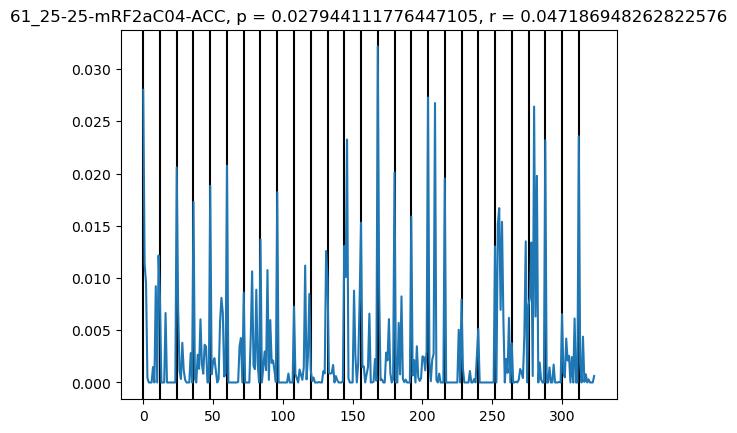

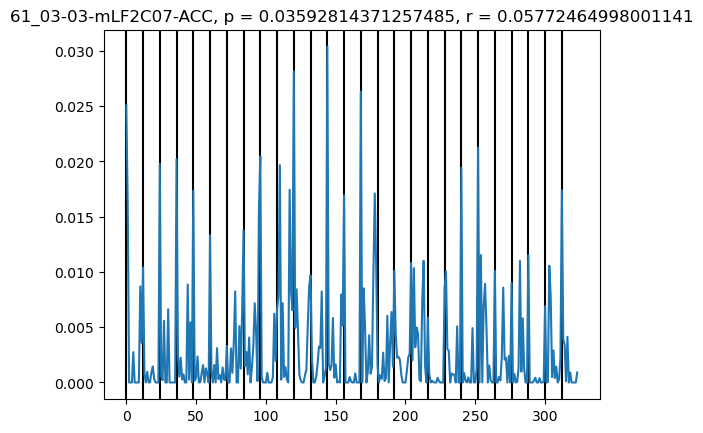

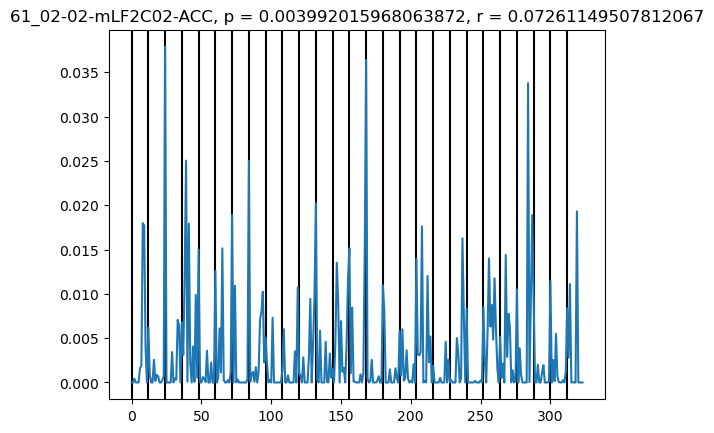

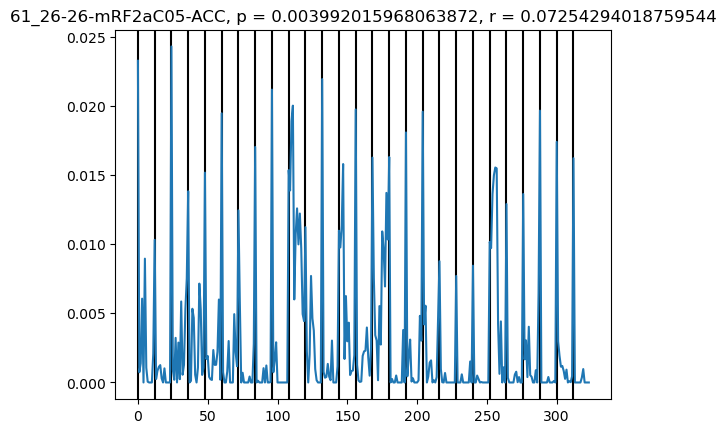

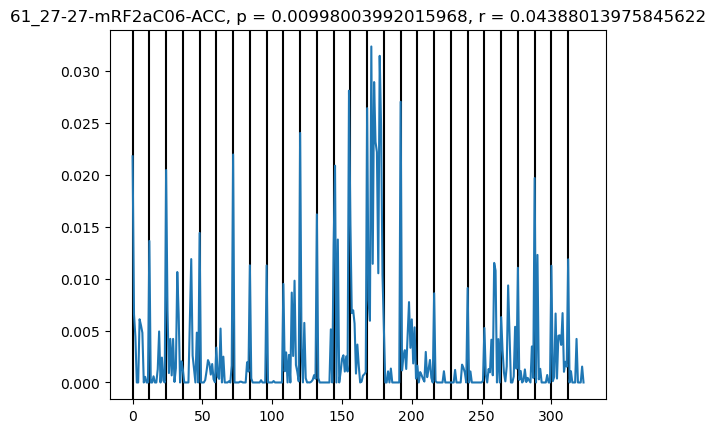

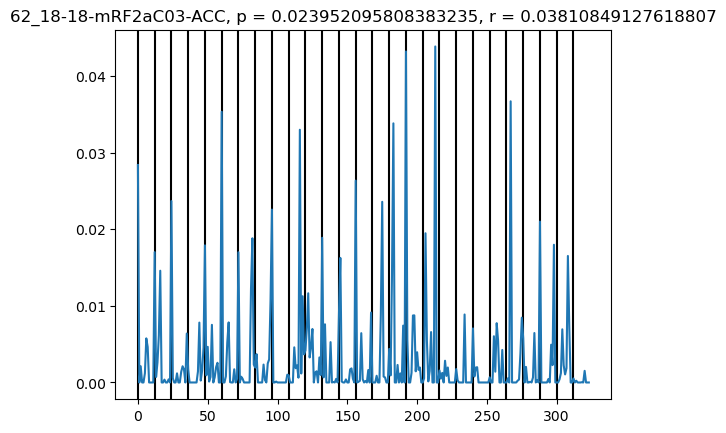

In [32]:
# plotting the ACC neurons.

acc_filter_df = dsr_coefs_df[dsr_coefs_df['roi'] == 'ACC']
for row in acc_filter_df.iloc:
    curr_neuron = row['neuron']
    plt.figure()
    for i in range(0,324,12):
        plt.axvline(i, color='black')
    plt.plot(row['coefs'])
    plt.title(f"{curr_neuron}, p = {row['p_perm']}, r = {row['mean_r']}")

    
    
    

In [30]:
print(row['coefs'].shape)


(324,)
